# Scikit learn / Keras tutorial

In [1]:
import numpy as np   # essential for everything
import pandas as pd   # data structure
import matplotlib.pyplot as plt   # plots
import seaborn as sns   # fanc plots
import sklearn   # standard machine learning
import keras   # neural networks (frontend for tensorflow)

In [2]:
from sklearn.datasets import load_wine

In [3]:
# load data
data = load_wine()
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
X = data['data']
y = data['target']
names = data['feature_names']

# Preprocessing and exploratory data analysis (EDA)
1. Compute the number of classes and the number of samples per class
2. Compute the mean and standard deviation per feature
3. Come up with some plots that can help you get an intuition for the data (e.g. how different fetures are related to each other and the label)
4. Shuffle the data along the sample axis (X and y)
5. Split the data into train (70%) and test set (30%)
6. Standardize the data (fit on train set, transform train and test set)

In [1]:
from sklearn.preprocessing import StandardScaler

In [5]:
# class counts:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([59, 71, 48], dtype=int64))

In [6]:
n_classes = 3

In [7]:
# means:
df = pd.DataFrame(X, columns=names)
df['cultivator'] = y

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivator
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


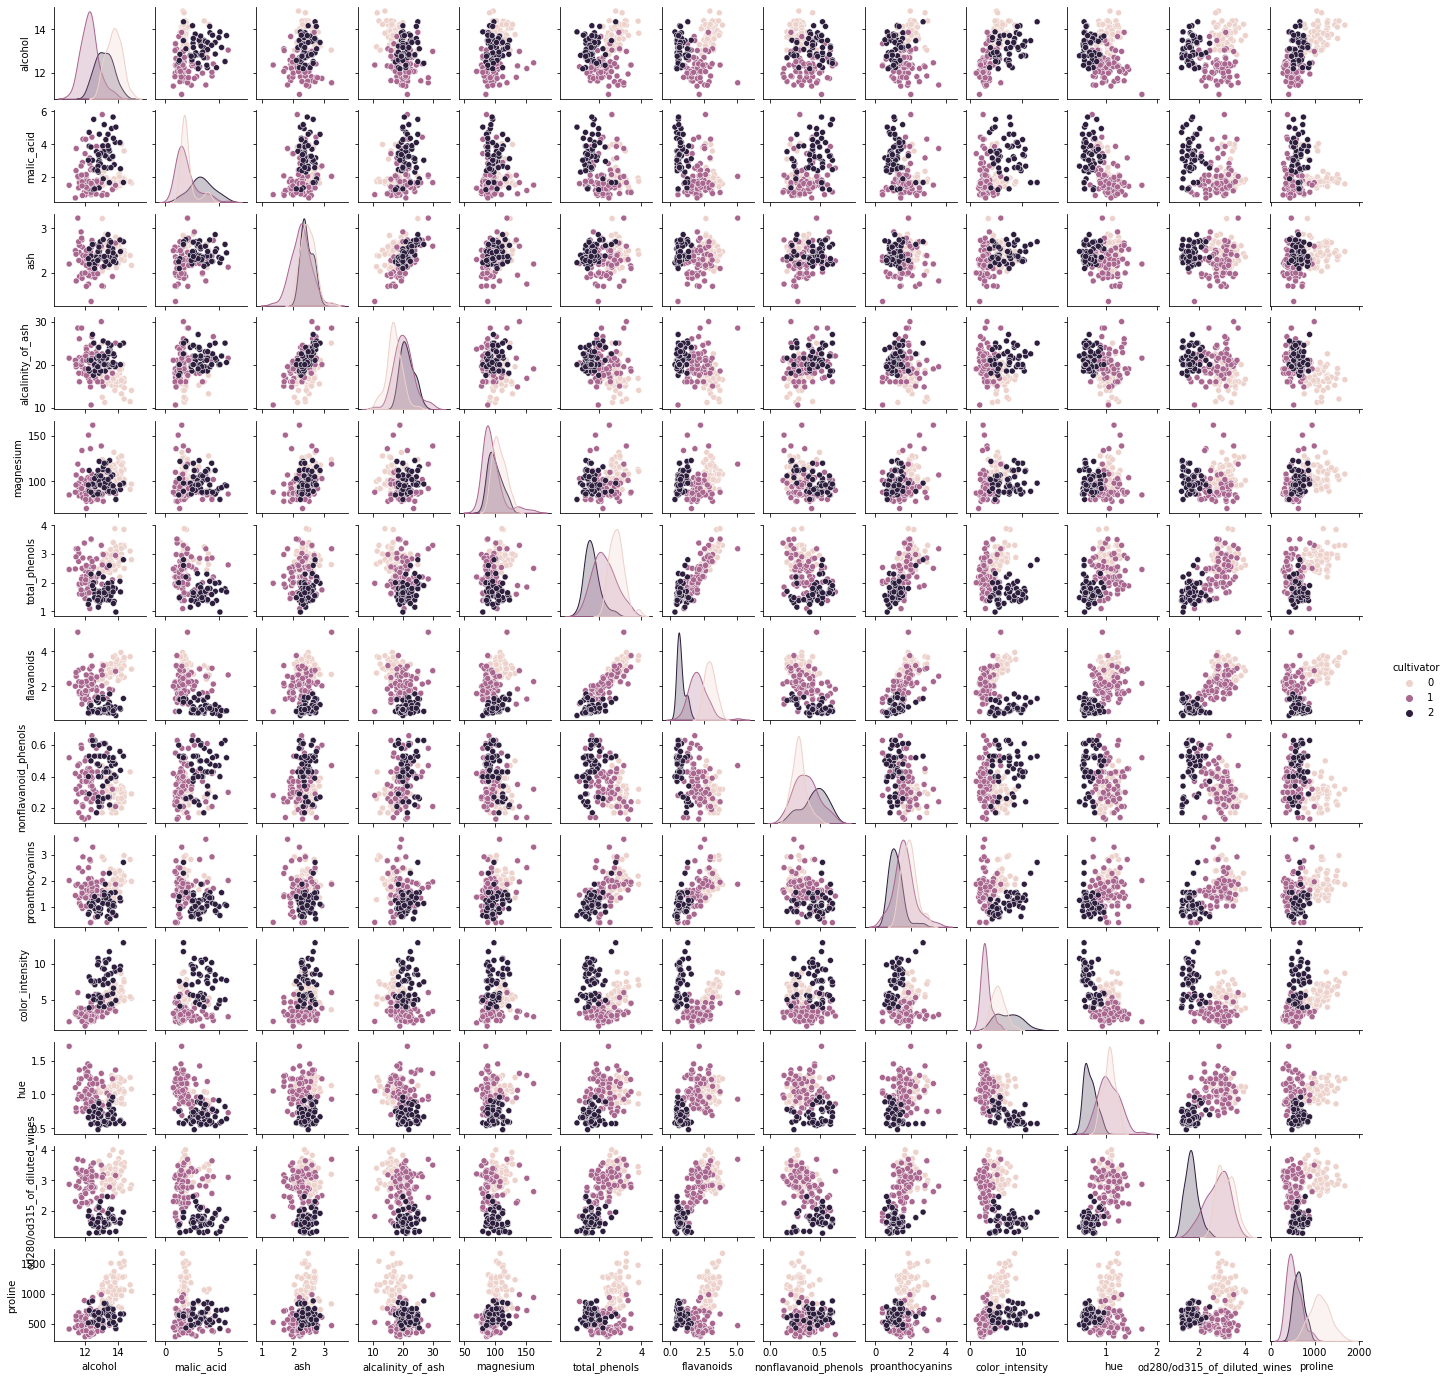

In [8]:
sns.pairplot(df, hue="cultivator", height=1.5)

In [9]:
# Shuffle:
np.random.seed(6542)
shuffled = np.arange(len(X))
np.random.shuffle(shuffled)
shuffled

array([ 75,  27,  38,   9, 138, 105, 168, 161,  33,  40,   0, 169, 139,
        59,   3, 131, 143,  91, 174, 142,   6,  86,  68,  85, 136, 167,
       119, 132,  16, 135, 163, 176,  48,  46, 112,  56, 164,  32,  64,
       118,  67,  77, 155, 111, 177, 144, 133,  24,  18,  17, 160, 110,
       173,  79,   8, 115,  70, 109, 129, 123, 141, 172,  62,  73, 100,
        69, 108, 103,  61,  37,  51, 102,  96, 113,   2,  83,  60, 146,
        54, 171,   5, 140,  44,  71, 127,  94,  14,  12,  43, 150,  28,
        58,  52,  11, 101, 134, 116,  20,  15,  30, 158, 126, 165, 170,
         7,  49,  23, 121,  13,  81,  10,  41,  47,  26, 130,  90, 148,
        35,  98, 151,  66,  92, 128,  82,  34,  63,  57, 153, 104,  29,
        39,   1, 120, 159,  93, 124, 166, 175, 157, 114,  78,  50,  36,
        95,  72, 137,  76,  53,  89,  31, 125, 149,  25, 145,  99, 152,
       162,  22,  74, 147,  97,  65,  80,  45, 106, 117,  88, 156,  21,
       154,   4,  42,  87, 107,  84,  19,  55, 122])

In [10]:
X = X[shuffled]
y = y[shuffled]

In [11]:
# Train / Test set
n_train = int(0.7*len(X))

X_train = X[:n_train]
X_test = X[n_train:]
y_train = y[:n_train]
y_test = y[n_train:]

In [12]:
# Standardize
scaler = StandardScaler().fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Logistic regression
1. Fit a logistic regression model on the training data
2. Use it to predict labels of the test data
3. Compute the accuracy of the model and store it in the acc dictionary
4. Plot the coefficients of each feature for each label

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
acc = {}

In [15]:
logreg = LogisticRegression(penalty='none',
                            fit_intercept=True, 
                            class_weight=None, 
                            random_state=47, 
                            solver='lbfgs', 
                            max_iter=1000, 
                            multi_class='auto', 
                            n_jobs=None)

In [16]:
logreg.fit(X_train,y_train)
y_pred = logreg.predict(X_test)
acc['logreg'] = accuracy_score(y_test, y_pred)
print(acc['logreg'])

LogisticRegression(max_iter=1000, penalty='none', random_state=47)

In [22]:
coefs_df = pd.DataFrame(logreg.coef_, columns=names)
coefs_df.T.plot.bar()

# Decision Trees
1. Fit a decision tree model on the training data
2. Use it to predict labels of the test data
3. Compute the accuracy of the model and store it in the acc dictionary
4. Plot the decision tree

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [25]:
tree = DecisionTreeClassifier()

tree.fit(X_train,y_train)
y_pred = tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.8888888888888888

In [26]:
acc['tree'] = accuracy_score(y_test, y_pred)

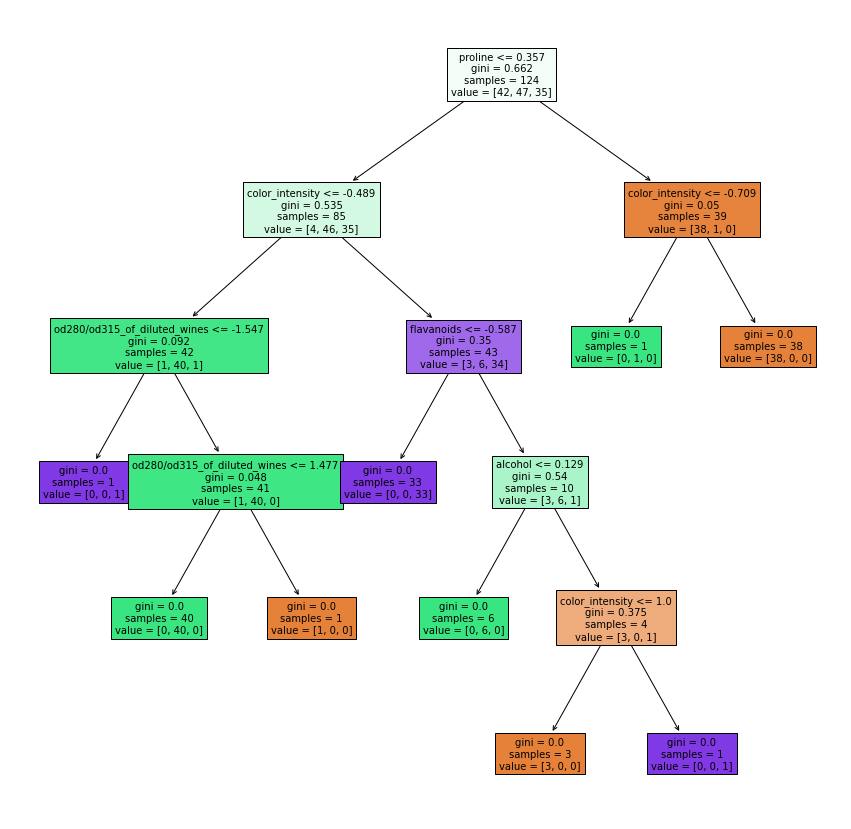

In [28]:
plt.figure(figsize=(15,15))
plot_tree(tree, filled=True, feature_names=names, fontsize=10)
plt.show()

# Random forest
1. Fit a random forest model on the training data
2. Use it to predict labels of the test data
3. Compute the accuracy of the model and store it in the acc dictionary

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=2,
                            random_state=3512)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
acc['random_forest'] = accuracy_score(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.9629629629629629

# Neural network
1. Fit a random forest model on the training data (you need to use the categorical labels y_train_cat)
2. Build a sequential model with one hidden layer with 15 neurons (Dense, activation relu) and one output layer (Dense, activation softmax)
3. Compile the model with loss categorical_crossentropy and the SGD optimizer. Also add accuracy to the computed metrics.
4. Print the modl summary. How many parameters does the model have?
5. Fit the model on the training data
6. Use it to predict labels of the test data
7. Compute the accuracy of the model and store it in the acc dictionary
8. Play around with different model architectures (adding layers, changing number of neurons, look up and try different layers)

In [31]:
from keras.models import Sequential  # simplest way to set up neural network model 
from keras.layers import Dense  # fully connected layer
from tensorflow.keras.optimizers import SGD  # stochastic gradient descent
import tensorflow as tf  # backend, we only use it to set random seed
from tensorflow.keras.utils import to_categorical

In [32]:
y_train_cat = to_categorical(y_train)

In [33]:
np.random.seed(457)
tf.random.set_seed(2468)

model = Sequential()

model.add(Dense(15, activation='relu', input_shape=X_train.shape[1:]))
model.add(Dense(n_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', 
              optimizer=SGD(learning_rate=0.01), 
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 15)                210       
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 80        
_________________________________________________________________
dense_2 (Dense)              (None, 3)                 18        
Total params: 308
Trainable params: 308
Non-trainable params: 0
_________________________________________________________________


In [35]:
model.fit(X_train, y_train_cat, epochs=50, validation_split=0.2, batch_size=4, verbose=0)
y_pred = np.argmax(model.predict(X_test), axis=1)

acc['nnet'] = accuracy_score(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.9629629629629629

# Compare
Plot a bar plot to compare the accuracy of all models

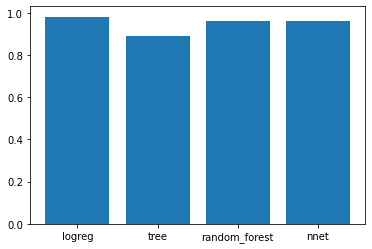

In [36]:
plt.bar(acc.keys(), acc.values())
plt.show()